In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [ ]:
sheet_id='1L7obsP1jXD3hfU7Tf01iEgmJemfh45TT'
sheet_name='1410882745'
url=f'https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={sheet_name}'

In [ ]:
df=pd.read_csv(url, index_col='student')

In [ ]:
df

,broccoli,brussels_sprouts,steak,pumpkin_pie,pizza,seafood,olives,pesto_pasta,curry,favorite_color,age
student,,,,,,,,,,,
Aysenur,5,6,10,7,8,10,10,8,7,Coral,31
Bengü,6,10,10,1,9,9,10,5,9,baby pink,49
Elcin,9,9,10,3,10,10,10,10,10,purple,43
Linh,6,3,9,4,6,8,3,5,4,White,41
Lisa,9,8,2,4,10,1,2,5,9,Cobalt Blue,35
Marcus,6,7,9,3,9,8,8,7,6,cyan,59
Mariia T,9,7,0,10,6,7,7,6,8,Green,30
Marvin,8,5,10,1,9,8,1,8,10,red,27
Niels,7,8,9,3,9,3,5,8,10,Green,47


In [ ]:
two_features_df= df.iloc[:, :2]
two_features_df

,broccoli,brussels_sprouts
student,,
Aysenur,5,6
Bengü,6,10
Elcin,9,9
Linh,6,3
Lisa,9,8
Marcus,6,7
Mariia T,9,7
Marvin,8,5
Niels,7,8


In [ ]:
two_features_kmeans=KMeans(n_clusters=5, random_state=123)
two_features_kmeans.fit(two_features_df)

KMeans(n_clusters=5, random_state=123)

In [ ]:
clusters=two_features_kmeans.labels_

In [ ]:
two_features_df['clusters']=clusters

In [ ]:
two_features_df.sort_values(by='clusters')

,broccoli,brussels_sprouts,clusters
student,,,
Linh,6,3,0
Marvin,8,5,0
Sama/Marlo,8,5,0
Sonja,8,5,0
Mariia T,9,7,1
Elcin,9,9,1
Lisa,9,8,1
Stefano,8,0,2
Aysenur,5,6,3


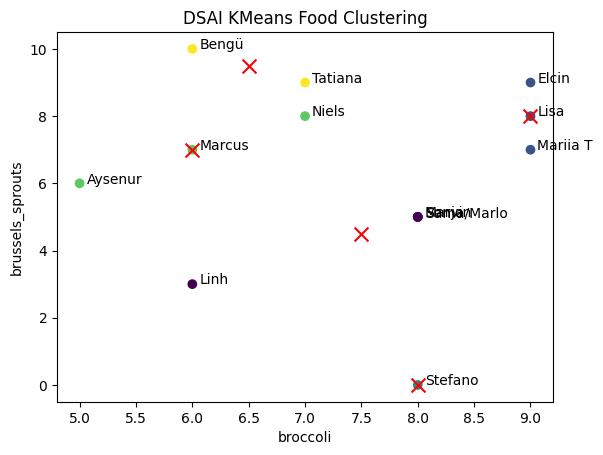

In [ ]:
plt.scatter(x=two_features_df.iloc[:, 0],
            y=two_features_df.iloc[:, 1],
            c=two_features_kmeans.labels_,
            cmap='viridis')

plt.scatter(x=two_features_kmeans.cluster_centers_[:,0],
            y=two_features_kmeans.cluster_centers_[:,1],
            c='red',
            marker='x',
            s=100)


for idx, row in two_features_df.iterrows():
    plt.annotate(idx, (row["broccoli"], row["brussels_sprouts"]), xytext=(5,0), textcoords='offset points')

plt.title('DSAI KMeans Food Clustering')
plt.xlabel(two_features_df.columns[0])
plt.ylabel(two_features_df.columns[1])
plt.show()